# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [1]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

In [2]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

In [3]:
# Your Code Here
x_train.shape

(50000, 32, 32, 3)

In [4]:
x_test.shape

(10000, 32, 32, 3)

Dimensions of each image is 32x32 pixels with 3 color channels (RGB).

In [5]:
y_train.shape

(50000, 1)

In [6]:
y_test.shape

(10000, 1)

In [7]:
# Print number of classes:
print(f'number of classes:{len(class_names)}')

number of classes:100


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_images(images, labels, class_names, num_images=6):
    plt.figure(figsize=(15, 15))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i][0]])
    plt.show()


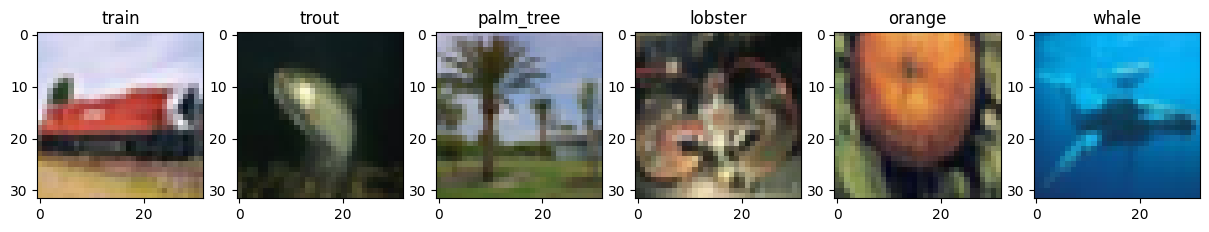

In [9]:
# Showing 6 random images from the training set
indices = np.random.choice(x_train.shape[0], 6, replace=False)
plot_images(x_train[indices], y_train[indices], class_names)


### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [10]:
# Your Code Here

# Normalizing the pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding
from tensorflow.keras.utils import to_categorical

print(f'Before one-hot encoding: {y_train[0]}')

y_train = to_categorical(y_train, num_classes=100)
y_test = to_categorical(y_test, num_classes=100)

print(f'After one-hot encoding: {y_train[0]}')

Before one-hot encoding: [19]
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [11]:
# Train test split:

from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(
    x_train,
    y_train,
    test_size=0.2, # 20% of the data is used for testing
    random_state=42 # Providing a value here means getting the same "random" split every time
)

In [12]:
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'y_test shape: {y_test.shape}')

x_train shape: (40000, 32, 32, 3)
y_train shape: (40000, 100)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 100)


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [13]:
# Your Code Here

from tensorflow.keras import layers, models

# Creating a Sequential model
model = models.Sequential()

# First Convolutional Block
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Second Convolutional Block
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flattening output of the convolutional layers
model.add(layers.Flatten())

# Fully Connected Layers
model.add(layers.Dense(128, activation='relu'))

# output layer

model.add(layers.Dense(100, activation='softmax'))

# Summary of the model
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          12,900 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 327,332 (1.25 MB)

 Trainable params: 327,332 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different.
- Briefly explain your choices (one or two sentences each).


- <b>Loss function:</b> categorical crossentropy because we are doing multi-class classification with 100 classes represented as one-hot encoded vectors
- <b>Optimizer:</b> adam because it dynamically optimizes learning rate

In [14]:
# Your Code Here

model.compile(
    optimizer='adam',  # adam optimizer
    loss='categorical_crossentropy',  # loss function for multi-class classification
    metrics=['accuracy']  # evaluation metric
)

## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [15]:
# Your Code Here

history = model.fit(
    x_train, # Training data
    y_train, # Training labels
    epochs=10, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.0597 - loss: 4.2453 - val_accuracy: 0.1730 - val_loss: 3.5000
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.2057 - loss: 3.3198 - val_accuracy: 0.2387 - val_loss: 3.1464
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.2670 - loss: 2.9776 - val_accuracy: 0.2645 - val_loss: 2.9822
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.3154 - loss: 2.7469 - val_accuracy: 0.2886 - val_loss: 2.9260
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 79s 39ms/step - accuracy: 0.3418 - loss: 2.5743 - val_accuracy: 0.3083 - val_loss: 2.8049
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.3842 - loss: 2.4115 - val_accuracy: 0.3171 - val_loss: 2.7689
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - accuracy: 0.4096 - loss: 2.2887 - val_accuracy: 0.3304 - val_loss: 2.7498
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.4351 -

Number of epoch chosen to be 10, as there is no improvement in accuracy after epoch 9.

In [16]:
loss, accuracy = model.evaluate(x_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.3386 - loss: 2.7524
Loss:     2.76
Accuracy: 33.48%


In [17]:
# Using a different metric: top-5 accuracy

from tensorflow.keras.metrics import TopKCategoricalAccuracy

model.compile(
    optimizer='adam',  # adam optimizer
    loss='categorical_crossentropy',  # loss function for multi-class classification
    metrics=[TopKCategoricalAccuracy(k=5)]  # evaluation metric
)

In [18]:
history_top5 = model.fit(
    x_train, # Training data
    y_train, # Training labels
    epochs=10, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - loss: 1.8862 - top_k_categorical_accuracy: 0.7923 - val_loss: 2.8376 - val_top_k_categorical_accuracy: 0.6323
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - loss: 1.7867 - top_k_categorical_accuracy: 0.8086 - val_loss: 2.8713 - val_top_k_categorical_accuracy: 0.6296
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - loss: 1.7193 - top_k_categorical_accuracy: 0.8220 - val_loss: 2.9126 - val_top_k_categorical_accuracy: 0.6339
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 74s 39ms/step - loss: 1.6371 - top_k_categorical_accuracy: 0.8361 - val_loss: 2.9529 - val_top_k_categorical_accuracy: 0.6289
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 1.5750 - top_k_categorical_accuracy: 0.8451 - val_loss: 3.0392 - val_top_k_categorical_accuracy: 0.6244
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - loss: 1.5012 - top_k_categorical_accuracy: 0.8521 - val_loss: 3.1740 - val_top_k_categorical_accuracy:

### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> 33.48%
- <b>Other metric:</b> _Top-K Accuracy where K=5
- <b>Reason for selection:</b> Top-K Accuracy checks the top k predictions rather than just the top prediction and can give us a general sense of whether the model is on track. A model may not be able to predict the exact correct class but the correct class can be within the top-5 predictions. This is useful because sometimes the model may be confident but still rank the true class lower in the probability list.
- <b>Value of metric:</b> 62.47%
- <b>Interpretation of metric value:</b> Top-5 accuracy is 62.47% which means that, in 62.47% of the test cases, the true label was among the top 5 predictions made by the model.

In [19]:
# Your Code Here
loss, top5_acc = model.evaluate(x_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Top-5 Accuracy: {top5_acc*100:.2f}%')


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 3.3560 - top_k_categorical_accuracy: 0.6233
Loss:     3.37
Top-5 Accuracy: 62.47%


### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

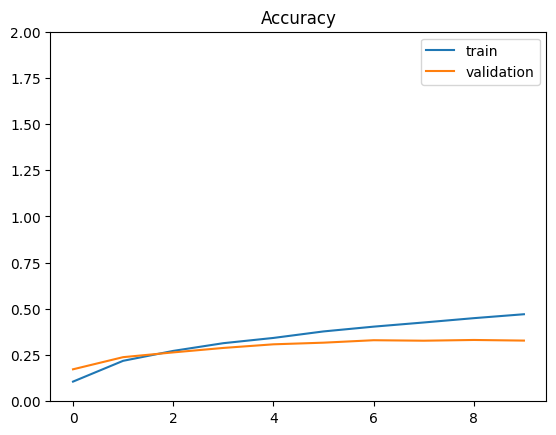

In [20]:
# Your Code Here

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Accuracy');

The training and validation accuracy plots for 10 epochs show a positive slope and we observe that over time the training accuracy steadily increases, showing that the model is learning and improving on the training set. Training accuracy is higher than the validation accuracy across all epochs, which is expected. Validation accuracy improves gradually though at a slower rate upto epoch 3, which shows that the model is learning to generalize new, unseen data. After epoch 3, the validation accuracy plateaus, which indicates that the model is overfitting.

In [21]:
#Selecting images

# model predictions
y_pred_test = model.predict(x_test)

# index of predicted labels
y_pred_label = np.argmax(y_pred_test, axis=1)

if len(y_test.shape) > 1:
    y_test_int = np.argmax(y_test, axis=1)  # Convert to integer labels

# Index where predictions match the true labels
right_pred = (y_pred_label == y_test_int)
right_index = np.where(right_pred)[0]

# Print index of correctly classified images
print(f"Indices of correctly classified images: {right_index}")

# Index where predictions do not match the true labels
wrong_pred = (y_pred_label != y_test_int)
wrong_index = np.where(wrong_pred)[0]

# Print index of incorrectly classified images
print(f"Indices of incorrectly classified images: {wrong_index}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Indices of correctly classified images: [   2    7    8 ... 9987 9990 9994]
Indices of incorrectly classified images: [   0    1    3 ... 9997 9998 9999]


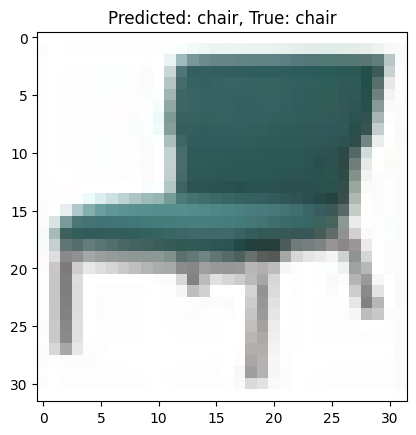

[4.68965908e-11 4.49640289e-08 1.20595714e-05 1.70623778e-07
 1.26402199e-06 9.93282255e-03 4.77962665e-08 8.63561763e-06
 2.37415534e-05 1.44759729e-03 2.42043083e-04 6.17647902e-06
 2.89110940e-05 2.22183553e-05 9.83718451e-07 9.15142118e-06
 3.54975520e-04 2.62265985e-07 3.89356064e-05 2.08791516e-06
 9.74257171e-01 8.53969839e-10 4.60251249e-05 1.12866837e-06
 1.10962814e-04 5.54867042e-03 1.86045145e-04 4.41807651e-06
 3.94550225e-05 1.63117147e-05 5.47855507e-07 9.63590452e-08
 3.37145975e-05 1.74074410e-06 3.38563694e-07 1.01882802e-06
 3.95332847e-07 3.27238070e-07 2.99272756e-07 1.76818238e-03
 7.12153851e-05 6.86616408e-09 1.14707916e-07 2.54927879e-09
 1.88784164e-04 1.89694993e-06 1.42038959e-06 1.22502328e-08
 1.14906360e-08 1.76115833e-09 1.25935412e-05 8.68977068e-08
 1.17982374e-10 8.05803063e-11 7.28641725e-09 4.38515599e-05
 2.25911867e-06 2.96939425e-06 4.19058506e-06 8.16661213e-07
 1.54620921e-06 1.10822630e-05 1.01101159e-11 9.87536950e-08
 3.40176740e-07 5.395346

In [53]:
# Select a random correctly classified image
correct_image = np.random.choice(right_index)

plt.imshow(x_test[correct_image])
plt.title(f"Predicted: {class_names[y_pred_label[correct_image]]}, True: {class_names[y_test_int[correct_image]]}")
plt.show()

# Model's classification probability for correct image
probab_correct = y_pred_test[correct_image]
print(probab_correct)


In [54]:
probab_correct_index= np.argmax(probab_correct)

print(f"Predicted class index: {probab_correct_index}")
print(f"Predicted class name: {class_names[probab_correct_index]}")
print(f"Predicted class probability: {probab_correct[probab_correct_index]:.4f}")

Predicted class index: 20
Predicted class name: chair
Predicted class probability: 0.9743


The model's classification probabilities indicate how confident the model is about an image belonging to a particular class. The class with the highest probability is the class that the model predicted for the image.

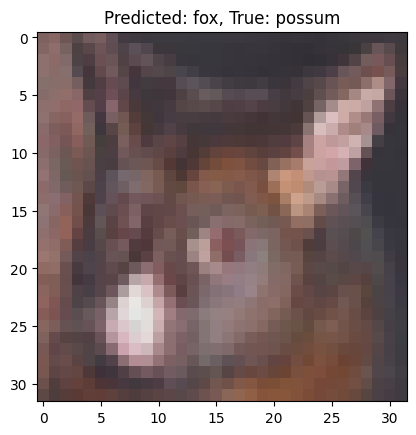

[1.09411398e-04 9.16502846e-04 2.03617588e-02 1.72102377e-02
 1.15612326e-02 5.92731871e-04 5.52760158e-03 8.54538113e-04
 1.30651472e-03 2.67203926e-04 5.21721260e-04 6.75556576e-03
 4.11617395e-04 5.46019464e-06 4.35493421e-03 4.74650040e-02
 2.45637901e-04 5.75448212e-04 7.60658551e-03 4.30816375e-02
 1.62617420e-03 4.96734574e-04 4.91052808e-04 8.31632715e-05
 6.01057196e-04 2.72095972e-03 5.11507550e-03 2.60096602e-02
 2.00164574e-03 2.24464238e-02 1.37400377e-04 6.21362627e-02
 4.21574991e-03 5.68245910e-03 7.70060867e-02 1.22582708e-02
 2.02888455e-02 1.43835100e-03 6.87936246e-02 2.18034815e-03
 2.44398892e-04 5.03771880e-04 4.35192659e-02 1.27108777e-02
 4.65445742e-02 3.36742727e-03 1.28021669e-02 9.05925408e-05
 2.64277460e-05 9.43136058e-07 2.98027396e-02 6.53079003e-02
 1.31716104e-06 4.40339363e-06 4.73291427e-03 1.23651391e-02
 1.43248646e-03 1.36335811e-03 5.68962037e-07 1.21103098e-04
 3.53432412e-08 8.69053656e-06 2.41178059e-05 2.01399513e-02
 1.42039722e-02 1.778553

In [61]:
# Select a random incorrectly classified image
incorrect_image = np.random.choice(wrong_index)

plt.imshow(x_test[incorrect_image])
plt.title(f"Predicted: {class_names[y_pred_label[incorrect_image]]}, True: {class_names[y_test_int[incorrect_image]]}")
plt.show()

# Model's classification probability for incorrect image
probab_incorrect = y_pred_test[incorrect_image]
print(probab_incorrect)

In [62]:
probab_incorrect_index= np.argmax(probab_incorrect)

print(f"Incorrect predicted class index: {probab_incorrect_index}")
print(f"Incorrect predicted class name: {class_names[probab_incorrect_index]}")
print(f"Incorrect predicted class probability: {probab_incorrect[probab_incorrect_index]:.4f}")


Incorrect predicted class index: 34
Incorrect predicted class name: fox
Incorrect predicted class probability: 0.0770


Here we randomly select an incorrect image and compute its class index, probability and class name. In this case, the model has labeled a possum as a fox. This is not unusual as they have similar visual features and the image is quite unclear.

## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [39]:
# Your Code Here

# Creating an advanced model
model2 = models.Sequential()

# First Convolutional Block
model2.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model2.add(layers.MaxPooling2D((2, 2)))
model2.add(layers.Dropout(0.2))  # Dropout layer


# Second Convolutional Block
model2.add(layers.Conv2D(64, (3, 3), activation='relu'))
model2.add(layers.MaxPooling2D((2, 2)))
model2.add(layers.Dropout(0.2))  # Dropout layer


# Flattening output of the convolutional layers
model2.add(layers.Flatten())

# Fully Connected Layers
model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.Dropout(0.4))  # Dropout layer


# output layer

model2.add(layers.Dense(100, activation='softmax'))

# Summary of the model
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 100)                 │          12,900 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 327,332 (1.25 MB)

 Trainable params: 327,332 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In this new model we utilized dropout regularization. We added dropout layers after the convolutional layers and the fully connected layers. Dropout helps to prevent overfitting by randomly setting a fraction of input units to zero during training. This helps the model to improve generalization rather than just memorizing the data.

The dropout rate in the dropout layers is the proportion of neurons in a given layer that are set to zero during training. For convolutional layers, a dropout rate of range 0.2 to 0.3 is typically used and a range of 0.4 to 0.5 is commonly used for dense layers. Hence we used 0.2 for convolutional layers and 0.4 for dense layers. We can also try different values and evaluate model performance before choosing a particular value. Due to high computational time requirements of each training for this model, we have chosen to work with the commonly used values for dropout rates, rather than experimenting with different values.

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

In [40]:
# Your Code Here
model2.compile(
    optimizer='adam',  # adam optimizer
    loss='categorical_crossentropy',  # loss function for multi-class classification
    metrics=['accuracy']  # evaluation metric
)

In [41]:
history_newmodel = model2.fit(
    x_train, # Training data
    y_train, # Training labels
    epochs=10, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split= 0.2 # Use 20% of the data for validation
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 44s 42ms/step - accuracy: 0.0355 - loss: 4.3985 - val_accuracy: 0.1328 - val_loss: 3.7337
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.1224 - loss: 3.7557 - val_accuracy: 0.1928 - val_loss: 3.4128
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.1618 - loss: 3.5096 - val_accuracy: 0.2188 - val_loss: 3.2705
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.1868 - loss: 3.3578 - val_accuracy: 0.2445 - val_loss: 3.1310
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.2108 - loss: 3.2417 - val_accuracy: 0.2670 - val_loss: 3.0200
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.2195 - loss: 3.1661 - val_accuracy: 0.2743 - val_loss: 2.9863
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.2358 - loss: 3.0814 - val_accuracy: 0.2850 - val_loss: 2.9293
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.2537 -

In [42]:
loss, accuracy = model2.evaluate(x_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.3175 - loss: 2.7550
Loss:     2.76
Accuracy: 31.29%


Comparing this accuracy value 31.29% with the one we obtained for task 3, we observe that there is no improvement in the accuracy, in fact there is a slight decrease for the same number of epochs. This is expected as dropout randomly drops a proportion of neurons, which makes the training process slower. We can observe the accuracy gradually increasing over the epochs. Dropout is expected to reduce overfitting and improve accuracy in the long run.

In [44]:
# Using a different metric for new model:

model2.compile(
    optimizer='adam',  # adam optimizer
    loss='categorical_crossentropy',  # loss function for multi-class classification
    metrics=[TopKCategoricalAccuracy(k=5)]  # evaluation metric
)

In [45]:
history_top5_new = model2.fit(
    x_train, # Training data
    y_train, # Training labels
    epochs=10, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 44s 42ms/step - loss: 2.8705 - top_k_categorical_accuracy: 0.5837 - val_loss: 2.7713 - val_top_k_categorical_accuracy: 0.6195
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - loss: 2.8157 - top_k_categorical_accuracy: 0.5969 - val_loss: 2.7584 - val_top_k_categorical_accuracy: 0.6191
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 83s 43ms/step - loss: 2.7673 - top_k_categorical_accuracy: 0.6083 - val_loss: 2.7838 - val_top_k_categorical_accuracy: 0.6165
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - loss: 2.7585 - top_k_categorical_accuracy: 0.6101 - val_loss: 2.7253 - val_top_k_categorical_accuracy: 0.6252
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - loss: 2.6935 - top_k_categorical_accuracy: 0.6228 - val_loss: 2.7207 - val_top_k_categorical_accuracy: 0.6220
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - loss: 2.6879 - top_k_categorical_accuracy: 0.6231 - val_loss: 2.6769 - val_top_k_categorical_accuracy:

In [63]:
loss, top5_acc_new = model2.evaluate(x_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Top-5 Accuracy: {top5_acc_new*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 2.6191 - top_k_categorical_accuracy: 0.6488
Loss:     2.63
Top-5 Accuracy: 65.05%


For the top-5 accuracy metric, the enhanced model gives a value of 65.05% compared to a value of 62.47% for the base model. Here we observe a slight improvement in accuracy. Dropout makes the model use a wider range of features as some features get dropped randomly. This causes thet model to explore diverse outcomes which can contribute to better top-5 predictions.

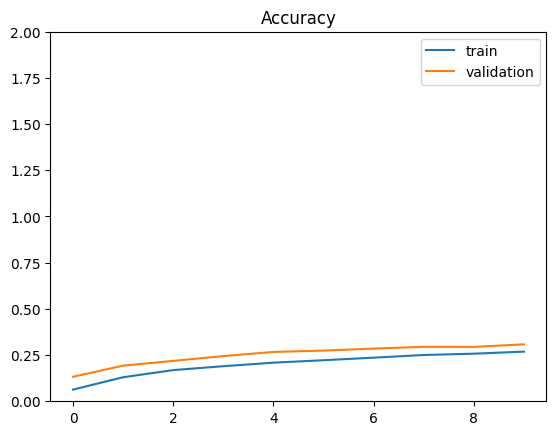

In [64]:
plt.plot(history_newmodel.history['accuracy'], label='train')
plt.plot(history_newmodel.history['val_accuracy'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Accuracy');

The accuracy plots show an upward trend for both the training and validation sets, which means that the model is on track and is gradually learning.

In [65]:
# new model predictions
y_pred_test = model2.predict(x_test)

# index of predicted labels
y_pred_label = np.argmax(y_pred_test, axis=1)

if len(y_test.shape) > 1:
    y_test_int = np.argmax(y_test, axis=1)  # Convert to integer labels

# Index where predictions match the true labels
right_pred = (y_pred_label == y_test_int)
right_index = np.where(right_pred)[0]

# Print index of correctly classified images
print(f"Indices of correctly classified images: {right_index}")

# Index where predictions do not match the true labels
wrong_pred = (y_pred_label != y_test_int)
wrong_index = np.where(wrong_pred)[0]

# Print index of correctly classified images
print(f"Indices of correctly classified images: {wrong_index}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Indices of correctly classified images: [   1    2    5 ... 9987 9994 9997]
Indices of correctly classified images: [   0    3    4 ... 9996 9998 9999]


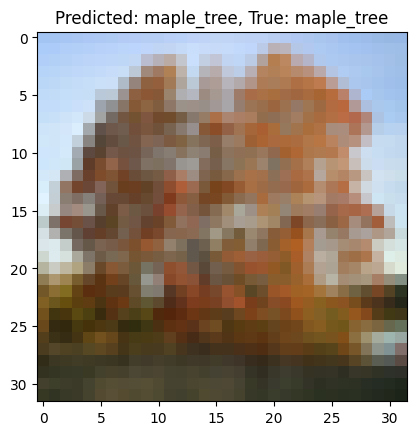

[5.87673092e-08 1.20778873e-06 2.28327444e-05 4.54701949e-04
 2.79540778e-04 4.44856778e-06 1.37317002e-05 9.98609380e-07
 1.65471647e-04 3.55340785e-06 5.53000518e-06 2.21427108e-05
 6.50606584e-04 7.89653350e-05 1.62574793e-07 6.75015152e-03
 4.90508455e-07 4.70681563e-02 7.54927760e-06 8.34404957e-04
 1.03378989e-06 2.01422267e-06 2.62779722e-05 2.03863829e-06
 5.37404476e-09 3.59059661e-04 3.56669807e-05 3.30975013e-06
 5.76199355e-08 2.03321758e-03 4.76197248e-10 4.10090294e-03
 1.38397887e-03 4.59887926e-03 9.52802584e-05 1.16794208e-05
 1.88671125e-04 2.80299056e-02 3.74514275e-05 2.97272454e-05
 5.70067641e-05 5.29999511e-07 5.08037570e-04 1.83071801e-03
 5.06989682e-06 4.43528370e-06 1.26646177e-04 2.72934139e-01
 1.00678812e-06 2.89188419e-03 3.17112535e-05 8.30437566e-05
 2.53808707e-01 4.15791774e-08 1.20401432e-06 2.24746200e-05
 3.10229021e-03 4.28346357e-05 1.15710391e-05 8.65013748e-02
 7.17050352e-05 1.66011660e-07 1.10221983e-08 1.90631326e-04
 4.32558591e-05 8.472886

In [67]:
# Select a random correctly classified image
correct_image = np.random.choice(right_index)

plt.imshow(x_test[correct_image])
plt.title(f"Predicted: {class_names[y_pred_label[correct_image]]}, True: {class_names[y_test_int[correct_image]]}")
plt.show()

# Model's classification probability for correct image
probab_correct = y_pred_test[correct_image]
print(probab_correct)

In [69]:
probab_correct_index= np.argmax(probab_correct)

print(f"Predicted class index: {probab_correct_index}")
print(f"Predicted class name: {class_names[probab_correct_index]}")
print(f"Predicted class probability: {probab_correct[probab_correct_index]:.4f}")

Predicted class index: 47
Predicted class name: maple_tree
Predicted class probability: 0.2729


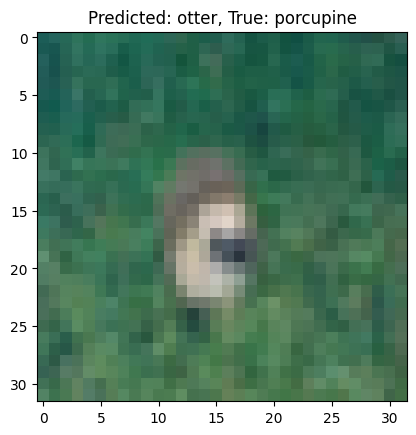

[7.7416356e-05 5.4157493e-03 6.2795967e-04 8.7067829e-03 2.2827236e-02
 9.4349979e-04 1.0755204e-03 5.7403743e-03 7.4130413e-04 1.4877745e-03
 1.2318672e-03 6.5710209e-04 2.3705673e-03 1.3476284e-04 3.4112332e-03
 5.0279382e-03 3.0745854e-04 6.5739098e-04 5.6815136e-02 8.4101083e-03
 5.7467008e-05 4.7467723e-03 1.2096185e-03 3.7228984e-03 4.1674748e-03
 1.2447739e-03 7.6478464e-03 6.6948496e-02 1.9403257e-03 5.8477763e-03
 1.9993534e-02 5.3198370e-03 1.3249200e-02 6.2968349e-03 8.3199320e-03
 5.2521913e-04 1.2694815e-03 1.4567634e-03 3.7369013e-02 2.2575448e-03
 1.3972763e-03 1.3932957e-03 3.4032462e-03 5.0846669e-03 3.0954314e-02
 7.5209560e-03 1.7938628e-03 1.1421500e-03 1.0032681e-04 1.5681544e-03
 2.2436084e-02 1.5429599e-02 1.7069794e-04 2.0022515e-05 8.7530422e-04
 7.2441749e-02 5.8702137e-03 2.5580833e-03 4.8426216e-05 2.6326065e-03
 2.5166583e-04 2.0324792e-04 8.2332372e-05 1.5852517e-02 2.7526999e-02
 4.8595183e-02 1.6039150e-02 5.6892116e-02 5.2087818e-04 3.3107011e-03
 3.411

In [70]:
# Select a random incorrectly classified image
incorrect_image = np.random.choice(wrong_index)

plt.imshow(x_test[incorrect_image])
plt.title(f"Predicted: {class_names[y_pred_label[incorrect_image]]}, True: {class_names[y_test_int[incorrect_image]]}")
plt.show()

# Model's classification probability for incorrect image
probab_incorrect = y_pred_test[incorrect_image]
print(probab_incorrect)

In [71]:
probab_incorrect_index= np.argmax(probab_incorrect)

print(f"Incorrect predicted class index: {probab_incorrect_index}")
print(f"Incorrect predicted class name: {class_names[probab_incorrect_index]}")
print(f"Incorrect predicted class probability: {probab_incorrect[probab_incorrect_index]:.4f}")

Incorrect predicted class index: 55
Incorrect predicted class name: otter
Incorrect predicted class probability: 0.0724


### Task 4c: Discussion of the results

- Briefly discuss the results.
- Did the model's performance improve?
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.

# Your answer here

From the above accuracy results for the enhanced model implemented using dropout layers, we observe no improvement for the same number of epochs. However, this is not unusual when dropout is applied to a neural network. In early stages of training, dropout can make the learning process slower for the model. We observe a gradual increase in accuracy with epochs which indicate that with time the model is learning to generalize better without depending on particular neurons. This is expected to improve accuracy over time.

We can further improve the model by changing the dropout rates and the learning rates or by using a different optimizer. Also we can use Batch Normalization, which standardizes the inputs to a layer so that they have a mean of 0 and a variance of 1 and can improve the performance and training speed of deep neural networks. We can experiment by combining these methods to improve generalization and the overall performance of the model.

## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.